In [1]:
from ravex import MultiPlanetSystem, maroonx_serval_error
import numpy as np
import astropy.units as u
import astropy.time as t
import matplotlib.pyplot as plt

In [2]:
# Define the host star mass
mass_star = 0.583 * u.solMass

# Define a single planet
planet1 = {
    "mass": 8.2 * u.earthMass,
    "time_periastron": t.Time("2024-03-22T20:42:17.000", format="isot", scale="utc"),
    "inclination": 90.0 * u.deg,
    "argument_periapse": 90.0 * u.deg,
    "eccentricity": 0.0,
    "orbital_period": 2.32 * u.day,
}

# Build the planetary system
system = MultiPlanetSystem(mass_star, [planet1])

In [3]:
# Build a dense and regular time grid over the same observing baseline
n_model = 10000
# Define the observing baseline
start_time = t.Time("2026-07-01T00:00:00", format="isot", scale="utc")
span_days = 120

time_grid = t.Time(
    start_time.jd + np.linspace(0, span_days, n_model),
    format="jd",
    scale="utc"
)

# Compute the noiseless RV model
jd_model, rv_model, phases_model, phased_model = system.get_rvs(time_grid)

In [4]:
rv_max = np.max(rv_model)
rv_min = np.min(rv_model)
K_est = 0.5 * (rv_max - rv_min)

print(f"Estimated semi-amplitude K: {K_est:.3f} m/s")

Estimated semi-amplitude K: 5.676 m/s


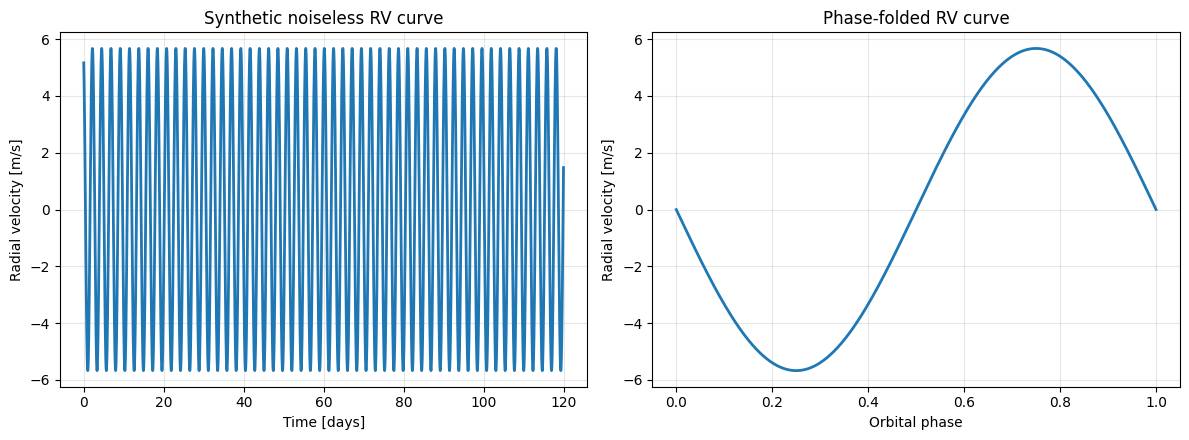

In [5]:
# Plot the theoretical noiseless RV curve in time and phase
time_days = jd_model - jd_model[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left panel: RV as a function of time
axes[0].plot(time_days, rv_model, lw=2)
axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel("Radial velocity [m/s]")
axes[0].set_title("Synthetic noiseless RV curve")
axes[0].grid(alpha=0.3)

# Right panel: RV as a function of orbital phase
axes[1].plot(phased_model["p0"]["phase"], phased_model["p0"]["rv"], lw=2)
axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("Radial velocity [m/s]")
axes[1].set_title("Phase-folded RV curve")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
# MAROON-X input from the ETC
snr_peak_red = 87   # example value from the ETC
snr_peak_blue = 52   # example value from the ETC

arm1 = "red"
arm2 = "blue"

# Estimated intrinsic SERVAL RV uncertainty for MAROON-X
sigma_maroonx_red = maroonx_serval_error(
    snr_peak=snr_peak_red,
    spectral_type="K7",   
    arm=arm1
)

sigma_maroonx_blue = maroonx_serval_error(
    snr_peak=snr_peak_blue,
    spectral_type="K7",  
    arm=arm2
)

# Assumed stellar jitter. Let's use a very conservative value for quiet K-stars (Wright 2005; Issacson & Ficher 2010)
sigma_jitter = 3.5  # m/s

# Total per-measurement uncertainty
sigma_eff_maroonx_red = np.sqrt(sigma_maroonx_red**2 + sigma_jitter**2)
sigma_eff_maroonx_blue = np.sqrt(sigma_maroonx_blue**2 + sigma_jitter**2)


print(f"MAROON-X ({arm1} arm) instrumental error: {sigma_maroonx_red:.3f} m/s")
print(f"Assumed stellar jitter: {sigma_jitter:.3f} m/s")
print(f"Total RV uncertainty per measurement: {sigma_eff_maroonx_red:.3f} m/s")
print("**********")
print(f"MAROON-X ({arm2} arm) instrumental error: {sigma_maroonx_blue:.3f} m/s")
print(f"Assumed stellar jitter: {sigma_jitter:.3f} m/s")
print(f"Total RV uncertainty per measurement: {sigma_eff_maroonx_blue:.3f} m/s")

MAROON-X (red arm) instrumental error: 2.577 m/s
Assumed stellar jitter: 3.500 m/s
Total RV uncertainty per measurement: 4.346 m/s
**********
MAROON-X (blue arm) instrumental error: 2.017 m/s
Assumed stellar jitter: 3.500 m/s
Total RV uncertainty per measurement: 4.039 m/s


In [7]:
from scipy.optimize import curve_fit

# -----------------------------
# Setup
# -----------------------------
start_time = t.Time("2026-07-01T00:00:00", format="isot", scale="utc")
planet_index = 0
n_obs = 50

true_mass = system.planets[planet_index]["mass"].to(u.earthMass).value
sigma_eff_red = sigma_eff_maroonx_red   # m/s
sigma_eff_blue = sigma_eff_maroonx_blue # m/s

# Different RNGs for dates and noise
rng_dates = np.random.default_rng(123)
rng_noise_red = np.random.default_rng(456)
rng_noise_blue = np.random.default_rng(789)

# -----------------------------
# Common observation dates
# -----------------------------
observation_dates = system.obs_dates(
    n_obs=n_obs,
    span_days=span_days,
    date_one=start_time,
    rng=rng_dates
)

# -----------------------------
# RVs simulated with noise: red
# -----------------------------
jd_obs_red, rv_obs_red, phases_obs_red, phased_obs_red = system.get_rvs(
    observation_dates,
    noise=sigma_eff_red * u.m / u.s,
    rng=rng_noise_red
)

# -----------------------------
# RVs simulated with noise: blue
# -----------------------------
jd_obs_blue, rv_obs_blue, phases_obs_blue, phased_obs_blue = system.get_rvs(
    observation_dates,
    noise=sigma_eff_blue * u.m / u.s,
    rng=rng_noise_blue
)

# -----------------------------
# Phase extraction and RV from each arm
# -----------------------------
phase_red = phased_obs_red[f"p{planet_index}"]["phase"]
y_red = phased_obs_red[f"p{planet_index}"]["rv"]
yerr_red = np.full_like(y_red, sigma_eff_red, dtype=float)

phase_blue = phased_obs_blue[f"p{planet_index}"]["phase"]
y_blue = phased_obs_blue[f"p{planet_index}"]["rv"]
yerr_blue = np.full_like(y_blue, sigma_eff_blue, dtype=float)

# -----------------------------
# Unification of arms
# -----------------------------
phase_joint = np.concatenate([phase_red, phase_blue])
y_joint = np.concatenate([y_red, y_blue])
yerr_joint = np.concatenate([yerr_red, yerr_blue])

# opcional: sort for phase
sort_idx = np.argsort(phase_joint)
phase_joint = phase_joint[sort_idx]
y_joint = y_joint[sort_idx]
yerr_joint = yerr_joint[sort_idx]

# -----------------------------
# Dense grid for the model 
# -----------------------------
n_dense = 10000
dense_dates = t.Time(
    start_time.jd + np.linspace(0, span_days, n_dense),
    format="jd",
    scale="utc"
)

# -----------------------------
# Model for the fit: only mass
# e=0, gamma=0
# -----------------------------
def fmodel(phase, mass):
    return system.model_for_fit(
        phase_obs=phase,
        mass=mass,
        eccentricity=0.0,
        observation_dates_dense=dense_dates,
        planet_index=planet_index,
        gamma=0.0
    )

p0 = [true_mass]
bounds = ([0.1], [30.0])

popt, pcov = curve_fit(
    fmodel,
    phase_joint,
    y_joint,
    p0=p0,
    bounds=bounds,
    sigma=yerr_joint,
    absolute_sigma=True,
    maxfev=20000
)

mass_fit = popt[0]
mass_err = np.sqrt(np.diag(pcov))[0]
mass_precision_pct = 100.0 * mass_err / mass_fit

print(f"True mass         = {true_mass:.3f} M_earth")
print(f"Recovered mass    = {mass_fit:.3f} ± {mass_err:.3f} M_earth")
print(f"Mass precision    = {mass_precision_pct:.2f} %")
print(f"Red points        = {len(y_red)}")
print(f"Blue points       = {len(y_blue)}")
print(f"Joint points      = {len(y_joint)}")

True mass         = 8.200 M_earth
Recovered mass    = 7.701 ± 0.901 M_earth
Mass precision    = 11.70 %
Red points        = 50
Blue points       = 50
Joint points      = 100


In [15]:
# Observation Grid: by twos
n_obs_list = np.arange(2, 51, 2)

# We assume here that the stellar jitter is common to both arms, i.e. not independent.
sigma_inst_joint = 1.0 / np.sqrt(
    1.0 / sigma_maroonx_red**2 +
    1.0 / sigma_maroonx_blue**2
)

sigma_eff_joint = np.sqrt(sigma_inst_joint**2 + sigma_jitter**2)

res_parallel = system.precision_tracker(
    planet_index=0,
    n_obs_list=n_obs_list,
    span_days=span_days,
    start_time=start_time,
    sigma_eff_known=sigma_eff_joint * u.m/u.s,
    fit_mode="mass_only",
    n_trials=100,
    rng_seed=42,
    verbose=False,
    n_jobs=32,                 # cambia esto si quieres
    chunksize=1,
    mp_start_method="fork",
)


print("sigma_eff joint usado [m/s]:", res_parallel["sigma_eff_mps"])
print("fit_mode:", res_parallel["fit_mode"])

sigma_eff joint usado [m/s]: 3.843458896138824
fit_mode: mass_only


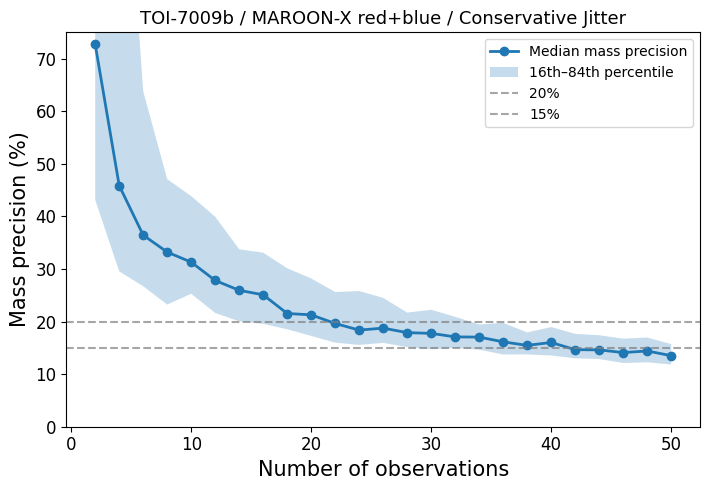

In [16]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))

n = res_parallel["n_obs"]
y = res_parallel["mass_precision_pct_med"]
y16 = res_parallel["mass_precision_pct_p16"]
y84 = res_parallel["mass_precision_pct_p84"]

ax.plot(n, y, "o-", lw=2, label="Median mass precision")
ax.fill_between(n, y16, y84, alpha=0.25, label="16th–84th percentile")

ax.axhline(20, ls="--", color="gray", alpha=0.7, label="20%")
ax.axhline(15, ls="--", color="gray", alpha=0.7, label="15%")
# ax.axhline(5,  ls="--", color="gray", alpha=0.7, label="5%")
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Number of observations", fontsize=15)
ax.set_ylabel("Mass precision (%)" , fontsize=15)
ax.set_ylim(0,75)
ax.set_title("TOI-7009b / MAROON-X red+blue / Conservative Jitter", fontsize=13)
ax.grid(False)
ax.legend()
plt.tight_layout()

# plt.savefig("MassPrecisionTracker_TOI7009b_red+blue_conservative.png", dpi=200, bbox_inches="tight")

plt.show()

In [17]:
from ravex import save_precision_tracker_to_csv

In [19]:
save_precision_tracker_to_csv(
    res_parallel,
    "results_toi7009b/toi7009b_precision_tracker_red_blue_conservative.csv"
)

Results saved to: results_toi7009b/toi7009b_precision_tracker_red_blue_conservative.csv


True mass         = 8.200 M_earth
Recovered mass    = 8.967 ± 1.287 M_earth
Mass precision    = 14.35 %
Red epochs        = 20
Blue epochs       = 20
Joint points      = 40


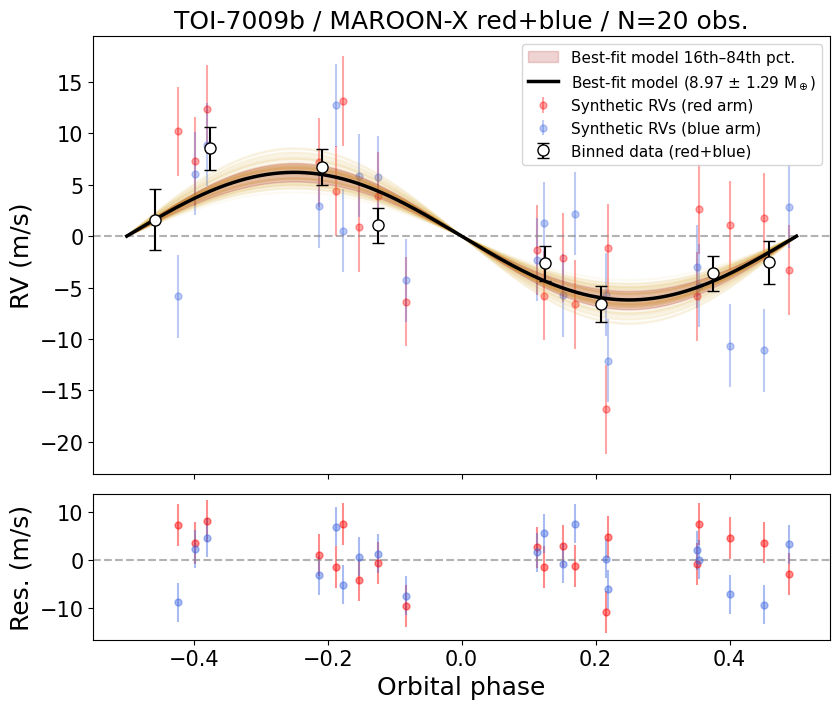

In [22]:
from scipy.optimize import curve_fit

# =========================================================
# Joint red+blue fit at the N that gives ~15% mass precision
# Assumption: N=20 means 20 common epochs, so we plot 20 red + 20 blue points
# =========================================================
planet_index = 0
n_obs = 20

true_mass = system.planets[planet_index]["mass"].to(u.earthMass).value
sigma_eff_red = sigma_eff_maroonx_red
sigma_eff_blue = sigma_eff_maroonx_blue

# Separate RNGs for reproducibility
rng_dates = np.random.default_rng(123)
rng_noise_red = np.random.default_rng(456)
rng_noise_blue = np.random.default_rng(789)

# ---------------------------------------------------------
# Common observing epochs
# ---------------------------------------------------------
observation_dates = system.obs_dates(
    n_obs=n_obs,
    span_days=span_days,
    date_one=start_time,
    rng=rng_dates
)

# ---------------------------------------------------------
# Simulated RVs for each arm
# ---------------------------------------------------------
jd_obs_red, rv_obs_red, phases_obs_red, phased_obs_red = system.get_rvs(
    observation_dates,
    noise=sigma_eff_red * u.m / u.s,
    rng=rng_noise_red
)

jd_obs_blue, rv_obs_blue, phases_obs_blue, phased_obs_blue = system.get_rvs(
    observation_dates,
    noise=sigma_eff_blue * u.m / u.s,
    rng=rng_noise_blue
)

phase_red = phased_obs_red[f"p{planet_index}"]["phase"]
y_red = phased_obs_red[f"p{planet_index}"]["rv"]
yerr_red = np.full_like(y_red, sigma_eff_red, dtype=float)

phase_blue = phased_obs_blue[f"p{planet_index}"]["phase"]
y_blue = phased_obs_blue[f"p{planet_index}"]["rv"]
yerr_blue = np.full_like(y_blue, sigma_eff_blue, dtype=float)

# ---------------------------------------------------------
# Joint arrays for the fit
# ---------------------------------------------------------
phase_joint = np.concatenate([phase_red, phase_blue])
y_joint = np.concatenate([y_red, y_blue])
yerr_joint = np.concatenate([yerr_red, yerr_blue])

sort_idx = np.argsort(phase_joint)
phase_joint = phase_joint[sort_idx]
y_joint = y_joint[sort_idx]
yerr_joint = yerr_joint[sort_idx]

# ---------------------------------------------------------
# Dense model grid
# ---------------------------------------------------------
n_dense = 10000
dense_dates = t.Time(
    start_time.jd + np.linspace(0, span_days, n_dense),
    format="jd",
    scale="utc"
)

# ---------------------------------------------------------
# Mass-only fit
# ---------------------------------------------------------
def fmodel(phase, mass):
    return system.model_for_fit(
        phase_obs=phase,
        mass=mass,
        eccentricity=0.0,
        observation_dates_dense=dense_dates,
        planet_index=planet_index,
        gamma=0.0
    )

p0 = [true_mass]
bounds = ([0.1], [30.0])

popt, pcov = curve_fit(
    fmodel,
    phase_joint,
    y_joint,
    p0=p0,
    bounds=bounds,
    sigma=yerr_joint,
    absolute_sigma=True,
    maxfev=20000
)

mass_fit = popt[0]
mass_err = np.sqrt(np.diag(pcov))[0]
mass_precision_pct = 100.0 * mass_err / mass_fit

print(f"True mass         = {true_mass:.3f} M_earth")
print(f"Recovered mass    = {mass_fit:.3f} ± {mass_err:.3f} M_earth")
print(f"Mass precision    = {mass_precision_pct:.2f} %")
print(f"Red epochs        = {len(y_red)}")
print(f"Blue epochs       = {len(y_blue)}")
print(f"Joint points      = {len(y_joint)}")

# ---------------------------------------------------------
# True model and best-fit model
# ---------------------------------------------------------
phase_model_true, rv_model_true = system.rv_model(
    dense_dates,
    mass=true_mass,
    eccentricity=0.0,
    planet_index=planet_index
)

phase_model_fit, rv_model_fit = system.rv_model(
    dense_dates,
    mass=mass_fit,
    eccentricity=0.0,
    planet_index=planet_index
)

# ---------------------------------------------------------
# Phase wrapping helper
# ---------------------------------------------------------
def wrap_phase(ph):
    phw = np.array(ph, dtype=float).copy()
    phw[phw > 0.5] -= 1.0
    return phw

phase_red_plot  = wrap_phase(phase_red)
phase_blue_plot = wrap_phase(phase_blue)
phase_true_plot = wrap_phase(phase_model_true)
phase_fit_plot  = wrap_phase(phase_model_fit)

ord_red  = np.argsort(phase_red_plot)
ord_blue = np.argsort(phase_blue_plot)
ord_true = np.argsort(phase_true_plot)
ord_fit  = np.argsort(phase_fit_plot)

# ---------------------------------------------------------
# Monte Carlo envelope from mass_fit ± mass_err
# ---------------------------------------------------------
rng_mc = np.random.default_rng(2026)
n_draws = 500

mass_draws = rng_mc.normal(loc=mass_fit, scale=mass_err, size=n_draws)
mass_draws = mass_draws[mass_draws > 0]

all_model_curves = []

for mdraw in mass_draws:
    ph_draw, rv_draw = system.rv_model(
        dense_dates,
        mass=mdraw,
        eccentricity=0.0,
        planet_index=planet_index
    )

    ph_draw_plot = wrap_phase(ph_draw)
    order = np.argsort(ph_draw_plot)
    all_model_curves.append(rv_draw[order])

all_model_curves = np.array(all_model_curves)

order_fit = np.argsort(phase_fit_plot)
phase_grid = phase_fit_plot[order_fit]
rv_best_sorted = rv_model_fit[order_fit]
rv_p16 = np.percentile(all_model_curves, 16, axis=0)
rv_p84 = np.percentile(all_model_curves, 84, axis=0)

# ---------------------------------------------------------
# Binning in phase (joint red+blue points)
# ---------------------------------------------------------
phase_joint_plot = wrap_phase(np.concatenate([phase_red, phase_blue]))
y_joint_plot = np.concatenate([y_red, y_blue])
yerr_joint_plot = np.concatenate([yerr_red, yerr_blue])

n_bins = 12
bins = np.linspace(-0.5, 0.5, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

binned_means = []
binned_errors = []

for i in range(n_bins):
    if i < n_bins - 1:
        mask = (phase_joint_plot >= bins[i]) & (phase_joint_plot < bins[i + 1])
    else:
        mask = (phase_joint_plot >= bins[i]) & (phase_joint_plot <= bins[i + 1])

    if np.sum(mask) >= 1:
        y_bin = y_joint_plot[mask]
        e_bin = yerr_joint_plot[mask]
        w = 1.0 / e_bin**2
        mean_rv = np.sum(w * y_bin) / np.sum(w)
        err_rv = np.sqrt(1.0 / np.sum(w))
    else:
        mean_rv = np.nan
        err_rv = np.nan

    binned_means.append(mean_rv)
    binned_errors.append(err_rv)

binned_means = np.array(binned_means)
binned_errors = np.array(binned_errors)

# ---------------------------------------------------------
# Residuals per arm
# ---------------------------------------------------------
y_fit_red = fmodel(phase_red, mass_fit)
y_fit_blue = fmodel(phase_blue, mass_fit)

residuals_red = y_red - y_fit_red
residuals_blue = y_blue - y_fit_blue

# ---------------------------------------------------------
# Final figure
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8.5, 7.2),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)

# Raw simulated points by arm
ax1.errorbar(
    phase_red_plot[ord_red],
    y_red[ord_red],
    yerr=yerr_red[ord_red],
    fmt='o',
    ms=5,
    color='red',
    ecolor='red',
    alpha=0.35,
    label='Synthetic RVs (red arm)',
    zorder=1
)

ax1.errorbar(
    phase_blue_plot[ord_blue],
    y_blue[ord_blue],
    yerr=yerr_blue[ord_blue],
    fmt='o',
    ms=5,
    color='royalblue',
    ecolor='royalblue',
    alpha=0.35,
    label='Synthetic RVs (blue arm)',
    zorder=1
)

# Spaghetti curves
n_spaghetti = 100
idx_show = rng_mc.choice(len(all_model_curves), size=min(n_spaghetti, len(all_model_curves)), replace=False)

for idx in idx_show:
    ax1.plot(
        phase_grid,
        all_model_curves[idx],
        color='goldenrod',
        alpha=0.06,
        lw=1.5,
        zorder=2
    )

# 16th-84th envelope
ax1.fill_between(
    phase_grid,
    rv_p16,
    rv_p84,
    color='firebrick',
    alpha=0.20,
    label='Best-fit model 16th–84th pct.',
    zorder=3
)

# Best-fit model
ax1.plot(
    phase_grid,
    rv_best_sorted,
    color='black',
    lw=2.5,
    label=f'Best-fit model ({mass_fit:.2f} ± {mass_err:.2f} M$_\\oplus$)',
    zorder=4
)

# Binned joint data
ax1.errorbar(
    bin_centers,
    binned_means,
    yerr=binned_errors,
    fmt='o',
    ms=8,
    markerfacecolor='white',
    markeredgecolor='black',
    ecolor='black',
    color='black',
    capsize=4,
    label='Binned data (red+blue)',
    zorder=5
)

ax1.axhline(0.0, ls='--', color='gray', alpha=0.6)
ax1.set_ylabel('RV (m/s)', fontsize=18)
ax1.set_title('TOI-7009b / MAROON-X red+blue / N=20 obs.', fontsize=18)
ax1.tick_params(axis="both", labelsize=15)
ax1.grid(False)
ax1.legend(fontsize=11)

# Residuals by arm
ax2.errorbar(
    phase_red_plot[ord_red],
    residuals_red[ord_red],
    yerr=yerr_red[ord_red],
    fmt='o',
    ms=5,
    color='red',
    ecolor='red',
    alpha=0.45
)

ax2.errorbar(
    phase_blue_plot[ord_blue],
    residuals_blue[ord_blue],
    yerr=yerr_blue[ord_blue],
    fmt='o',
    ms=5,
    color='royalblue',
    ecolor='royalblue',
    alpha=0.45
)

ax2.axhline(0.0, ls='--', color='gray', alpha=0.6)
ax2.set_xlabel('Orbital phase', fontsize=18)
ax2.set_ylabel('Res. (m/s)', fontsize=18)
ax2.tick_params(axis="both", labelsize=15)
ax2.grid(False)

plt.tight_layout()
# plt.savefig("fitting_TOI7009b_RED_BLUE_N20.png", dpi=200, bbox_inches="tight")
plt.show()